In [14]:
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers
import numpy as np


In [15]:
(X_train,_), (_,_) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype('float32')/255 

X_train = np.reshape(X_train,(-1, 28 , 28 , 1))

In [ ]:
#Build generator

latend_dim = 100 

generator = keras.Sequential([
    layers.Input(shape=(latend_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(28*28, activation='sigmoid'),
    layers.Reshape((28,28,1))
])

generator.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 128)               12928     
                                                                 
 dense_11 (Dense)            (None, 784)               101136    
                                                                 
 reshape_2 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
Total params: 114,064
Trainable params: 114,064
Non-trainable params: 0
_________________________________________________________________


In [17]:
#Build Descriminator

discriminator = keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])
discriminator.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_12 (Dense)            (None, 128)               100480    
                                                                 
 dense_13 (Dense)            (None, 1)                 129       
                                                                 
Total params: 100,609
Trainable params: 100,609
Non-trainable params: 0
_________________________________________________________________


In [18]:
discriminator.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [19]:
discriminator.trainable = False 

gan_input = keras.Input(shape=(latend_dim,))

fake_image = generator(gan_input)

gan_output = discriminator(fake_image)

gan = keras.Model(gan_input, gan_output)


gan.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

gan.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 100)]             0         
                                                                 
 sequential_3 (Sequential)   (None, 28, 28, 1)         114064    
                                                                 
 sequential_4 (Sequential)   (None, 1)                 100609    
                                                                 
Total params: 214,673
Trainable params: 114,064
Non-trainable params: 100,609
_________________________________________________________________


In [21]:
epochs = 5000
batch_size = 128

for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, X_train.shape[0],batch_size)
    real_images = X_train[idx]

    noise = np.random.normal(0,1, (batch_size,latend_dim))
    fake_image = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_image, np.zeros((batch_size, 1)))

    #Train Generator
    noise = np.random.normal(0,1, (batch_size,latend_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))


    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}|"
              f"D_loss: {d_loss_real[0]:.4f}|"
              f"G Loss: {g_loss[0]:.4f}"
        )




Epoch: 0|D_loss: 0.4911|G Loss: 0.7053
Epoch: 1000|D_loss: 0.0583|G Loss: 2.8270
Epoch: 2000|D_loss: 0.0576|G Loss: 2.8991
Epoch: 3000|D_loss: 0.0369|G Loss: 3.2506
Epoch: 4000|D_loss: 0.0490|G Loss: 2.7931


In [22]:
# generate images

noise = np.random.normal(0,1, (10,latend_dim))

generated_images = generator.predict(noise,verbose=0)


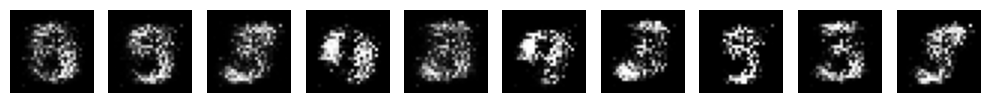

In [24]:
#Display Generated Images
import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 2))

for i in range(10):

    plt.subplot(1, 10, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()